In [ ]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import copy
import seaborn as sns

#Gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models import HdpModel

# Sklearn
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD, PCA
from sklearn.manifold import TSNE, MDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

Functions to output and save table, graph, and topic breakdowns given LDA model.

In [ ]:
def topicBreakdown(df, model, dictionary, filename):
    taxonomy = pd.read_csv('../metag_topic_modeling/data_sets/HMP_V13_taxonomy_fix.csv')
    result = ''

    # Detect if model is LDA or HDP
    if hasattr(model, "num_topics"):  
        # LDA
        topic_ids = range(model.num_topics)
        get_terms = lambda i: model.get_topic_terms(i, topn=10)
    else:  
        # HDP
        topics = model.show_topics(num_topics=-1, num_words=10, formatted=False)
        topic_ids = [topic_id for topic_id, _ in topics]
        topic_word_dict = {topic_id: words for topic_id, words in topics}
        get_terms = lambda i: [(dictionary.token2id[word], weight) for word, weight in topic_word_dict[i]]

    # Iterate topics
    for i in topic_ids:
        result += f"Topic {i}: "
        for term_id, weight in get_terms(i):
            word = dictionary[term_id]

            # match taxonomy
            row = taxonomy[taxonomy['OTU_ID'] == word]
            if not row.empty:
                result += str(row.iat[0, 6]) + ' '
            else:
                result += "Not Found "
        result += "\n"

    output_filename = f"results2/{str(model)}_topic_breakdown_gensim.txt"
    with open(output_filename, 'w') as f:
        f.write(result)

    print(f"Topic breakdown saved to {output_filename}")
    print(result)

In [ ]:
def bubblePlot1(df, model, dictionary, filename):
    taxonomy = pd.read_csv('../metag_topic_modeling/data_sets/HMP_V13_taxonomy_fix.csv')
    topic_data = []

    # Detect model type
    if hasattr(model, "num_topics"):  
        # LDA
        topic_ids = range(model.num_topics)
        get_terms = lambda i: model.get_topic_terms(i, topn=10)
    else:  
        # HDP
        topics = model.show_topics(num_topics=-1, num_words=10, formatted=False)
        if not topics:
            print("Warning: HDP model returned no topics!")
        topic_ids = [topic_id for topic_id, _ in topics]
        topic_word_dict = {topic_id: words for topic_id, words in topics}

        def get_terms_safe(i):
            terms = []
            for word, weight in topic_word_dict[i]:
                word_lower = word.lower()  # match dictionary in lowercase
                if word_lower in dictionary.token2id:
                    terms.append((dictionary.token2id[word_lower], weight))
                else:
                    # Use None as term_id for unmatched words
                    terms.append((None, weight))
            return terms
        get_terms = get_terms_safe

    # Collect topic data
    for i in topic_ids:
        top_terms = get_terms(i)

        for term_id, importance in top_terms:
            if term_id is not None:
                word = dictionary[term_id]
            else:
                word = None  # unmatched word

            if word is not None:
                row = taxonomy[taxonomy['OTU_ID'] == word]
                family_name = row.iat[0, 6] if not row.empty else "Not Found"
            else:
                family_name = "Not Found"

            topic_data.append({"Topic": f"Topic {i}", "Family": family_name, "Importance": importance})

    
    print("topic_data sample:", topic_data[:5])
    print("Number of entries:", len(topic_data))

    # convert to dataframe
    df_plot = pd.DataFrame(topic_data)

    # aggregate importance values for each (Topic, Family)
    df_agg = df_plot.groupby(["Topic", "Family"], as_index=False).sum()

    # bubble plot
    plt.figure(figsize=(10, 6))
    bubble = sns.scatterplot(
        data=df_agg,
        x="Topic",
        y="Family",
        size="Importance",
        hue="Importance",
        sizes=(20, 1000),
        palette="viridis",
        edgecolor="black",
        alpha=0.7
    )

    plt.xticks(rotation=45)
    plt.xlabel("Topic")
    plt.ylabel("Taxonomic Family")
    plt.title("Bubble Plot of Taxonomic Families per Topic")
    plt.legend(title="Importance")
    plt.tight_layout()

    # Save and show
    output_filename = f"results2/{str(model)}_topic_bubble_plot_gensim.png"
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"Bubble plot saved to {output_filename}")

Original graph

In [ ]:
body_sites = pd.read_csv('../metag_topic_modeling/data_sets/HMP_V13_participant_data.csv')

body_site_mapping = {site: idx for idx, site in enumerate(body_sites['HMP_BODY_SUBSITE'].unique())}

body_site_ints = body_sites['HMP_BODY_SUBSITE'].map(body_site_mapping)

In [ ]:
def bubblePlot2(df, model, dictionary, filename, corpus):
    
    # detect topic count
    if hasattr(model, "num_topics"):
        num_topics = model.num_topics  # LDA
    else:
        num_topics = len(model.show_topics(num_topics=-1, formatted=False))  # HDP

    samples = pd.read_csv(f"data_sets/{filename}/{filename}_otu.csv")

    psn_list = samples["PSN"].astype(str).tolist()

    # find topic distributions for each document
    topic_distributions = []
    for doc_bow in corpus:
        doc_topics = model.get_document_topics(doc_bow, minimum_probability=0)
        # Convert to full vector (pad to num_topics)
        topic_vector = np.zeros(num_topics)
        for topic_id, prob in doc_topics:
            if topic_id < num_topics:  # safeguard
                topic_vector[topic_id] = prob
        topic_distributions.append(topic_vector)

    topic_distributions = np.array(topic_distributions)

    # assign strongest topic
    strongest_topic_indices = topic_distributions.argmax(axis=1)
    
    topic_assign_df = pd.DataFrame({
        "PSN": psn_list,
        "Strongest_Topic": strongest_topic_indices
    })

    body_sites["PSN"] = body_sites["PSN"].astype(str)
    topic_assign_df["PSN"] = topic_assign_df["PSN"].astype(str)
    # merge with metadata by PSN
    merged = body_sites.merge(topic_assign_df, on="PSN", how="inner")

    # count topics by site
    topic_counts_by_site = (
        merged.groupby(["HMP_BODY_SUBSITE", "Strongest_Topic"])
              .size()
              .reset_index(name="Count")
    )

    print(topic_counts_by_site)

    table_filename = f"results2/{str(model)}_table_gensim.csv"
    topic_counts_by_site.to_csv(table_filename, index=False)
    print(f"Table saved to {table_filename}")

    # bubble plot
    plt.figure(figsize=(12, 7))
    bubble = sns.scatterplot(
        data=topic_counts_by_site,
        x="Strongest_Topic",
        y="HMP_BODY_SUBSITE",
        size="Count",
        hue="Count",
        sizes=(20, 1000),
        palette="viridis",
        edgecolor="black",
        alpha=0.7
    )

    plt.xticks(rotation=45)
    plt.xlabel("Strongest Topic")
    plt.ylabel("Body Site")
    plt.title("Bubble Plot of Topic Assignments by Body Site")
    plt.legend(title="Sample Count", loc='upper right')
    plt.tight_layout()

    output_filename = f"results2/{str(model)}_bubble_plot_gensim.png"
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"Bubble plot saved to {output_filename}")

In [ ]:
def outputTableandGraph(df, model, dictionary, filename, corpus):

    # detect topic count
    if hasattr(model, "num_topics"):
        num_topics = model.num_topics  # LDA
    else:
        num_topics = len(model.show_topics(num_topics=-1, formatted=False))  # HDP

    samples = pd.read_csv(f"data_sets/{filename}/{filename}_otu.csv")

    psn_list = samples["PSN"].astype(str).tolist()

    # compute topic distributions for each document
    topic_distributions = []
    for doc_bow in corpus:
        doc_topics = model.get_document_topics(doc_bow, minimum_probability=0)
        # convert to full vector
        topic_vector = np.zeros(num_topics)
        for topic_id, prob in doc_topics:
            if topic_id < num_topics:  # safeguard
                topic_vector[topic_id] = prob
        topic_distributions.append(topic_vector)
    topic_distributions = np.array(topic_distributions)

    # assign strongest topic
    strongest_topic_indices = topic_distributions.argmax(axis=1)
    
    topic_assign_df = pd.DataFrame({
        "PSN": psn_list,
        "Strongest_Topic": strongest_topic_indices
    })

    body_sites["PSN"] = body_sites["PSN"].astype(str)
    topic_assign_df["PSN"] = topic_assign_df["PSN"].astype(str)
    # merge with metadata by PSN
    merged = body_sites.merge(topic_assign_df, on="PSN", how="inner")

    # count topics by site
    topic_counts_by_site = (
        merged.groupby(["HMP_BODY_SUBSITE", "Strongest_Topic"])
              .size()
              .reset_index(name="Count")
    )
    print(topic_counts_by_site)

    # save table
    table_filename = f"results2/{str(model)}_table_gensim.csv"
    topic_counts_by_site.to_csv(table_filename)
    print(f"Table saved to {table_filename}")

    # map topics to integers for plotting
    LDA_mapping = {topic: idx for idx, topic in enumerate(body_sites['Strongest_Topic'].unique())}
    LDA_ints = body_sites['Strongest_Topic'].map(LDA_mapping)


    '''
    # plot
    custom_colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'pink', 'brown', 'olive', 'cyan']
    cmap = ListedColormap(custom_colors)

    fig = plt.figure(1, figsize=(8, 8))
    plt.clf()
    scatter = plt.scatter(result[:, 0], result[:, 1], c=LDA_ints, cmap=cmap, s=15)
    plot_filename = f"results/{filename}_comp_plot_gensim.svg"
    plt.savefig(plot_filename)
    print(f"Plot saved to {plot_filename}")
    plt.show()
    '''

Function to find optimal component number for each taxonomic level by perplexity, returning a graph and a table at that level.

Combined function

In [80]:
def generateModels(file_name):
    # load dataset
    df = pd.read_csv(f"data_sets/{file_name}/{file_name}_otu.csv")
    df = df.drop(df.columns[0], axis=1)  # drop index column if present

    # convert frequency to bag of words
    texts = []
    for row in df.itertuples(index=False):
        doc = []
        for word, count in zip(df.columns, row):
            doc.extend([word] * int(count))
        texts.append(doc)

    dictionary = Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # get # topics from HDP
    hdp = HdpModel(corpus=corpus, id2word=dictionary)
    topic_weights = hdp.hdp_to_lda()[0]
    threshold = 0.03
    topic_count = np.sum(topic_weights > threshold)
    print(f"HDP inferred ~{topic_count} topics")
    hdp_lda = hdp.suggested_lda_model()

    topic_weights = hdp_lda.get_topics().sum(axis=1)
    topic_weights = topic_weights / topic_weights.sum()

    top_topic_ids = topic_weights.argsort()[::-1][:topic_count]
    top_topics = hdp_lda.get_topics()[top_topic_ids]

    hdp_truncated = LdaModel(
        id2word=hdp_lda.id2word,
        num_topics=len(top_topic_ids),
        dtype=hdp_lda.dtype
    )

    hdp_truncated.state.sstats = top_topics.copy()
    hdp_truncated.sync_state()

    # run LDA with symmetric priors
    lda1 = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=topic_count,
        random_state=0,
        passes=10
    )

    #run LDA with automatically chosen priors
    lda2 = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=topic_count,
        random_state=0,
        passes=10,
        alpha="auto",
        eta="auto"
    )

    return lda1, lda2, hdp_truncated, df, dictionary, corpus

In [81]:
def analyzeModel(df, model, dictionary, file_name, corpus):
    topicBreakdown(df, model, dictionary, file_name)
    bubblePlot1(df, model, dictionary, file_name)
    bubblePlot2(df, model, dictionary, file_name, corpus)
    #outputTableandGraph(df, model, dictionary, file_name, corpus)

In [82]:
lda1, lda2, hdp, df, dictionary, corpus = generateModels("gut")

HDP inferred ~11 topics


Topic breakdown saved to results2/LdaModel<num_terms=8048, num_topics=11, decay=0.5, chunksize=2000>_topic_breakdown_gensim.txt
Topic 0: Bacteroidaceae Alcaligenaceae Bacteroidaceae Alcaligenaceae Bacteroidaceae Bacteroidaceae Rikenellaceae Alcaligenaceae Bacteroidaceae Rikenellaceae 
Topic 1: Lachnospiraceae Prevotellaceae Bacteroidaceae Bacteroidaceae Rikenellaceae Bacteroidaceae Prevotellaceae Bacteroidaceae Bacteroidaceae Prevotellaceae 
Topic 2: Bacteroidaceae Rikenellaceae nan Lachnospiraceae Lachnospiraceae Lachnospiraceae nan Bacteroidaceae Bacteroidaceae Lachnospiraceae 
Topic 3: Bacteroidaceae Bacteroidaceae Bacteroidaceae Bacteroidaceae Bacteroidaceae Bacteroidaceae Bacteroidaceae Bacteroidaceae Alcaligenaceae Bacteroidaceae 
Topic 4: Bacteroidaceae Bacteroidaceae Bacteroidaceae Bacteroidaceae Lachnospiraceae Lachnospiraceae Bacteroidaceae Veillonellaceae Bacteroidaceae Bacteroidaceae 
Topic 5: Bacteroidaceae Prevotellaceae Prevotellaceae Prevotellaceae Verrucomicrobiaceae R

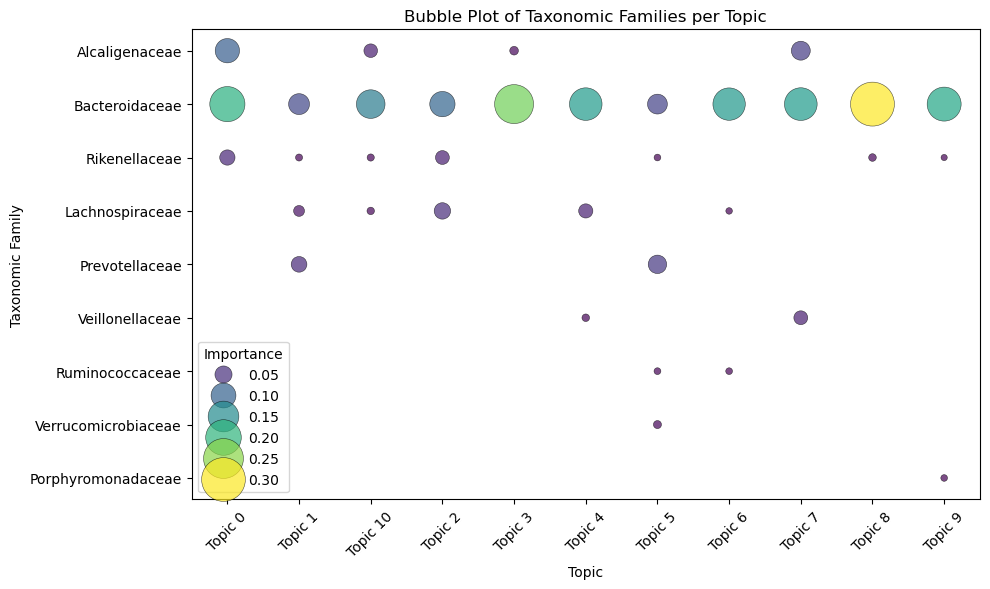

Bubble plot saved to results2/LdaModel<num_terms=8048, num_topics=11, decay=0.5, chunksize=2000>_topic_bubble_plot_gensim.png
   HMP_BODY_SUBSITE  Strongest_Topic  Count
0             Stool                0     10
1             Stool                1     20
2             Stool                2     18
3             Stool                3      8
4             Stool                4     29
5             Stool                5     12
6             Stool                6     17
7             Stool                7     17
8             Stool                8     20
9             Stool                9     16
10            Stool               10     20
Table saved to results2/LdaModel<num_terms=8048, num_topics=11, decay=0.5, chunksize=2000>_table_gensim.csv


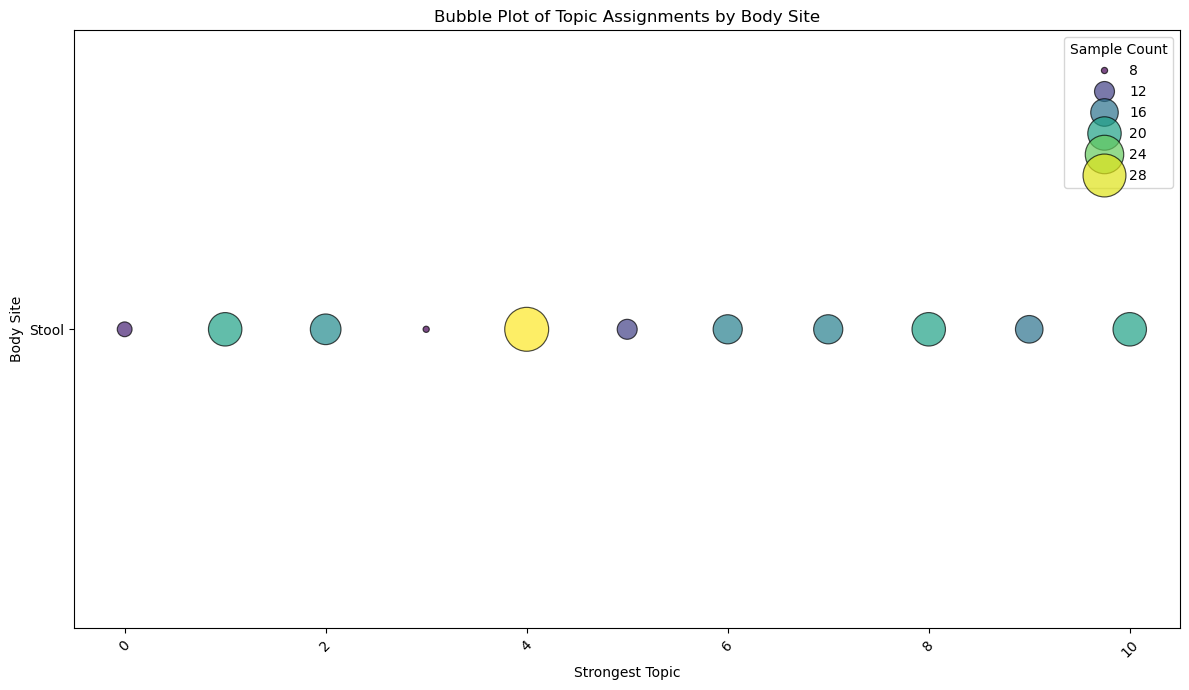

Bubble plot saved to results2/LdaModel<num_terms=8048, num_topics=11, decay=0.5, chunksize=2000>_bubble_plot_gensim.png


In [83]:
analyzeModel(df, lda2, dictionary, "gut", corpus)

In [84]:
lda1, lda2, hdp, df, dictionary, corpus = generateModels("oral")

HDP inferred ~4 topics


Topic breakdown saved to results2/LdaModel<num_terms=23912, num_topics=4, decay=0.5, chunksize=2000>_topic_breakdown_gensim.txt
Topic 0: Burkholderiaceae Streptococcaceae Streptococcaceae Neisseriaceae Neisseriaceae Campylobacteraceae Flavobacteriaceae Burkholderiaceae Flavobacteriaceae Neisseriaceae 
Topic 1: Streptococcaceae Streptococcaceae Streptococcaceae Gemellaceae Streptococcaceae Streptococcaceae Streptococcaceae Streptococcaceae Gemellaceae Streptococcaceae 
Topic 2: Campylobacteraceae Veillonellaceae Veillonellaceae Veillonellaceae Veillonellaceae Streptococcaceae Lachnospiraceae Streptococcaceae Veillonellaceae nan 
Topic 3: Veillonellaceae Neisseriaceae Neisseriaceae Carnobacteriaceae Streptococcaceae Porphyromonadaceae Fusobacteriaceae Veillonellaceae Neisseriaceae Veillonellaceae 

topic_data sample: [{'Topic': 'Topic 0', 'Family': 'Burkholderiaceae', 'Importance': 0.020518085}, {'Topic': 'Topic 0', 'Family': 'Streptococcaceae', 'Importance': 0.020358969}, {'Topic': 'Top

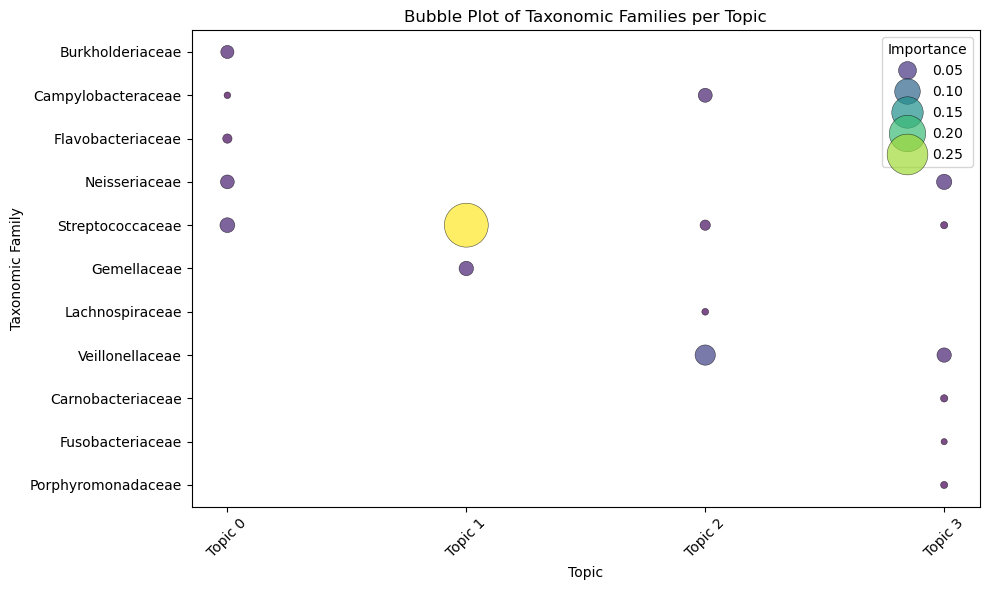

Bubble plot saved to results2/LdaModel<num_terms=23912, num_topics=4, decay=0.5, chunksize=2000>_topic_bubble_plot_gensim.png
                HMP_BODY_SUBSITE  Strongest_Topic  Count
0   Attached Keratinized Gingiva                0      8
1   Attached Keratinized Gingiva                1    170
2   Attached Keratinized Gingiva                2      2
3   Attached Keratinized Gingiva                3      1
4                  Buccal Mucosa                0     14
5                  Buccal Mucosa                1    149
6                  Buccal Mucosa                2      5
7                  Buccal Mucosa                3     15
8                    Hard Palate                0      1
9                    Hard Palate                1     60
10                   Hard Palate                2     42
11                   Hard Palate                3     75
12              Palatine Tonsils                0     15
13              Palatine Tonsils                1     12
14              Pal

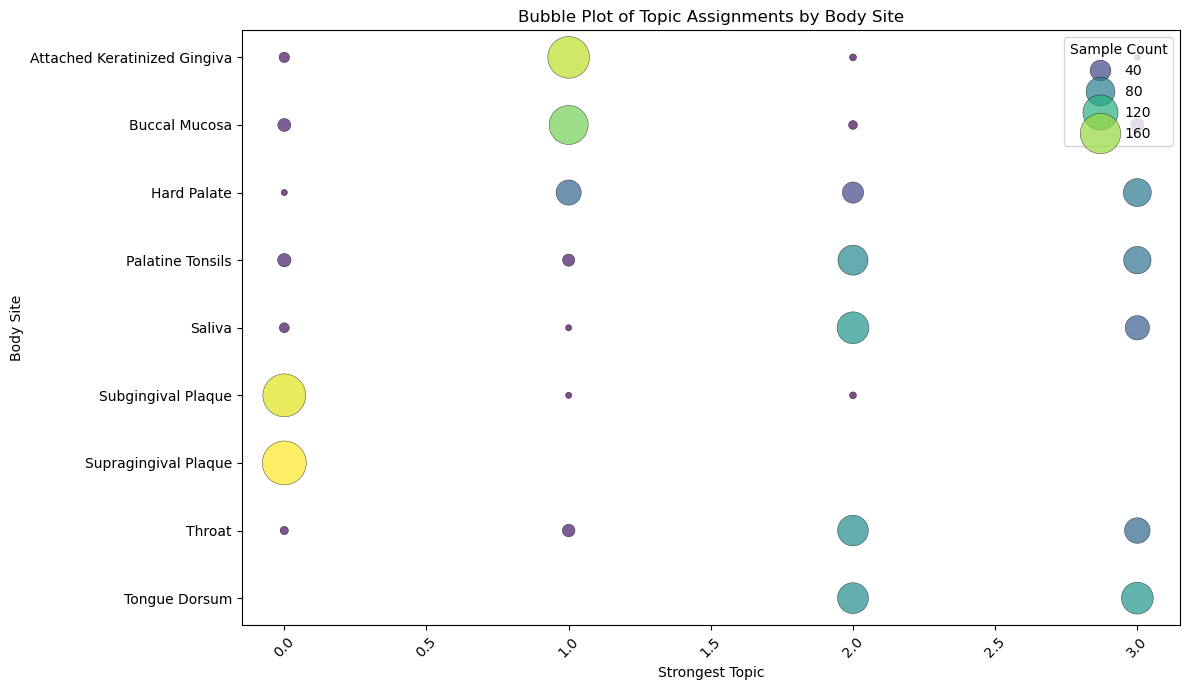

Bubble plot saved to results2/LdaModel<num_terms=23912, num_topics=4, decay=0.5, chunksize=2000>_bubble_plot_gensim.png


In [85]:
analyzeModel(df, lda2, dictionary, "oral", corpus)